# Spin Hall conductivity

author: Jae-Mo Lihm (jaemo.lihm@gmail.com) and Minsu Ghim (minsu.ghim.physics@gmail.com)

In this tutorial, we calculate the spin Berry curvature and the spin Hall conductivity of bcc Platinum. We compare the two methods for calculating the spin velocity matrix, which we call the "Qiao" method [1] and the "Ryoo" method [2].

[1] [J. Qiao et al, Phys. Rev. B 98, 214402 (2018)](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.98.214402) <br>
[2] [J. H. Ryoo et al, Phys. Rev. B 99, 235113 (2019)](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.99.235113)

Both methods use the Kubo formula to calculate spin Hall conductivity under time-reversal symmetry:

\begin{equation}
\sigma^{{\rm SHC}, \gamma}_{\alpha\beta} = \frac{-e\hbar}{N_k V_c}\sum_{\bf k}\sum_{n,m}\left(f_{n{\bf k}}-f_{m{\bf k}}\right)\frac{\textrm{Im}\left[\langle\psi_{n{\bf k}}\vert \frac{1}{2}\{ s^{\gamma}, v_\alpha \} \vert\psi_{m{\bf k}}\rangle\langle\psi_{m{\bf k}}\vert v_\beta\vert\psi_{n{\bf k}}\rangle\right]}{(\varepsilon_{n{\bf k}}-\varepsilon_{m{\bf k}})^2-(\hbar\omega+i\eta)^2}\,,
\label{eq:shc}\tag{1}
\end{equation}

where $\alpha$, $\beta$, $\gamma$ are respectively the direction of spin current, applied electric field, and spin polarisation.

The "Ryoo" method requires `.chk`, `.eig`, `.mmn`, `.spn`, `.sHu`, and `.sIu` files to calculate the spin velocity matrix in (\ref{eq:shc}), $\langle\psi_{n{\bf k}}\vert \frac{1}{2}\{ s^{\gamma}, v_\alpha \} \vert\psi_{m{\bf k}}\rangle$,from pw2wannier90.x,
while the "Qiao" method does not use the last two files, and instead applies an approximation $\mathbf{1}=\sum_{l\in \it{ab\,initio}} \vert u_{l{\bf q}}\rangle\langle u_{l{\bf q}}\vert$.
The `sHu` and `sIu` files are calculated by setting `write_sHu = .true.` and `write_sIu = .true.` to the `pw2wannier90.x` input file: see `data_Pt/pw2wan.in`.

In [1]:
# Preliminary (Do only once)
%load_ext autoreload
%autoreload 2

# Set environment variables - not mandatory but recommended
import os
os.environ['OPENBLAS_NUM_THREADS'] = '1' 
os.environ['MKL_NUM_THREADS'] = '1'


import wannierberri as wberri
import numpy as np
import matplotlib.pyplot as plt

## If the following lines are removed, calculations will be performed sequentially
import ray
ray.init(num_cpus=16) # Adjust this to the number of CPU cores you want to use

/home/stepan/github/WannierBerri-tutorial/.conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-30 23:44:51,727	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-03-30 23:44:53,722	INFO worker.py:1918 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8267 


Python version:,3.12.12
Ray version:,2.48.0
Dashboard:,http://127.0.0.1:8267


## Model, band structure

We load the system from a Wannier90 output. Note the arguments `SHCryoo=True` and `SHCqiao=True` which are required to compute spin Hall conductivity using the Ryoo and Qiao methods, respectively.

We set symmetry using the `set_symmetry_from_structure` method, which calls spglib to automatically determine the symmetry of the system.

<!-- We also symmetrize the system. See `data_Pt/Pt.win` file and check that the initial projections are correct. For details, refer to the symmetrization tutorial. -->

In [4]:
wandata = wberri.WannierData.from_w90_files("../data_Pt/Pt", files=["chk", "mmn", "eig", "sHu", "sIu", "spn"])
system = wberri.System_R.from_wannierdata(wandata, berry=True, SHCryoo=True, SHCqiao=True)
system.set_structure([[0., 0., 0.]], ["Pt"])
system.set_symmetry_from_structure()

efermi = 18.1605

Reading restart information from file ../data_Pt/Pt.chk :
Time to read .chk : 0.012336015701293945
Shells found with weights [0.77529491] and tolerance 1.940778946878804e-16
----------
  sHu   
---------
reading object of class SHU from file ../data_Pt/Pt.sHu with formatted=False bk_reorder={0: [0, 1, 2, 3, 4, 5, 6, 7], 1: [1, 2, 3, 4, 0, 5, 6, 7], 2: [1, 2, 3, 4, 0, 5, 6, 7], 3: [3, 1, 2, 4, 0, 5, 6, 7], 4: [1, 2, 3, 4, 5, 0, 6, 7], 5: [2, 3, 4, 5, 1, 0, 7, 6], 6: [2, 3, 4, 5, 1, 0, 7, 6], 7: [4, 2, 3, 5, 1, 0, 7, 6], 8: [1, 2, 3, 4, 5, 0, 6, 7], 9: [2, 3, 4, 5, 1, 0, 7, 6], 10: [2, 3, 4, 5, 1, 0, 7, 6], 11: [4, 2, 3, 5, 1, 0, 7, 6], 12: [1, 3, 2, 4, 5, 0, 6, 7], 13: [2, 4, 3, 5, 1, 0, 7, 6], 14: [2, 4, 3, 5, 1, 0, 7, 6], 15: [4, 3, 2, 7, 1, 0, 6, 5], 16: [1, 2, 3, 4, 5, 6, 0, 7], 17: [2, 3, 4, 5, 1, 7, 0, 6], 18: [2, 3, 4, 5, 1, 7, 0, 6], 19: [4, 2, 3, 5, 1, 7, 0, 6], 20: [2, 3, 4, 5, 7, 1, 0, 6], 21: [4, 5, 6, 7, 3, 2, 1, 0], 22: [4, 5, 6, 7, 3, 2, 1, 0], 23: [6, 4, 5, 7, 3, 2, 1, 0

In [6]:
path = wberri.Path.from_nodes(
    system,
    nodes=[
        [0.25, 0.75, 0.50], # W
        [0.50, 0.50, 0.50], # L
        [0.00, 0.00, 0.00], # Gamma
        [0.50, 0.00, 0.50], # X
        [0.50, 0.25, 0.75], # W
        [0.00, 0.00, 0.00], # Gamma
    ],
    labels=["W", "L", "$\Gamma$", "X", "W", "$\Gamma$"],
    length=300,
)

path_tab_result = wberri.evaluate_k_path(system, path=path)

Starting run()
Using the follwing calculators : 
############################################################

 'tabulate'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x74a9642e2810>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
--------------------------------------------------
 "Energy" : <wannierberri.calculators.tabulate.Energy object at 0x74a930181cd0> : calculator not described

--------------------------------------------------

############################################################
Calculation along a path - checking calculators for compatibility
tabulate <wannierberri.calculators.tabulate.TabulatorAll object at 0x74a9642e2810>
All calculators are compatible
Symmetrization switched off for Path
Grid is regular
The set of k points is a Path() with 322 points and labels {0: 'W', 54: 'L', 120: '$\\Gamma$', 197: 'X', 235: 'W', 321: '$\\Gamma$'}
generating K_list
Done 
Done, sum of weights:

/home/stepan/github/wannier-berri/wannierberri/grid/path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


time for processing    322 K-points on  16 processes:     0.7551 ; per K-point          0.0023 ; proc-sec per K-point          0.0375
time1 =  4.76837158203125e-07
Totally processed 322 K-points 
run() finished


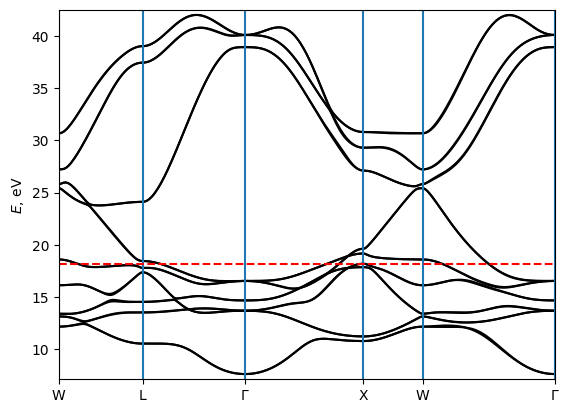

In [7]:
fig = path_tab_result.plot_path_fat(path, close_fig=False, show_fig=False)

ax = fig.get_axes()[0]
ax.axhline(efermi, c="r", ls="--")
plt.show(fig)

## Static spin Hall conductivity

We calculate the static (i.e. DC) spin Hall conductivity. We fix $\omega$ to 0 and scan the Fermi energy.

In [8]:
from wannierberri import calculators as calc

efermi_list = np.linspace(efermi - 1.0, efermi + 1.0, 101, True)

kwargs = dict(
    Efermi=efermi_list,
    omega=np.array([0.]),
    smr_fixed_width = 0.1, # Smearing for frequency in eV
    kBT = 0.026, # Smearing for Fermi level (Fermi-Dirac factor) in eV (not Kelvin)
)

calculators = dict(
    SHC_ryoo = calc.dynamic.SHC(SHC_type="ryoo", **kwargs),
    SHC_qiao = calc.dynamic.SHC(SHC_type="qiao", **kwargs),
)

In [ ]:
nk = 30
grid = wberri.Grid(system, NK=nk)
result = wberri.run(
    system,
    grid=grid,
    calculators=calculators
)

Minimal symmetric FFT grid :  [4 4 4]
Starting run()
Using the follwing calculators : 
############################################################

 'SHC_ryoo'  :  <wannierberri.calculators.dynamic.SHC object at 0x74a920478710>  : calculator not described
 'SHC_qiao'  :  <wannierberri.calculators.dynamic.SHC object at 0x74a9204af440>  : calculator not described
############################################################
Calculation on  grid - checking calculators for compatibility
SHC_ryoo <wannierberri.calculators.dynamic.SHC object at 0x74a920478710>
SHC_qiao <wannierberri.calculators.dynamic.SHC object at 0x74a9204af440>
All calculators are compatible
Grid is regular
The set of k points is a Grid() with NKdiv=[6 6 6], NKFFT=[5 5 5], NKtot=[30 30 30]
generating K_list
Done in 0.0009431838989257812 s 
excluding symmetry-equivalent K-points from initial grid
Done in 0.025480270385742188 s 
K_list contains 16 Irreducible points(7.41%) out of initial 6x6x6=216 grid
Done, sum of weights

The SHC data has 5 indices:
1. The Fermi level index,
2. The frequency index,
3. The spin current direction index,
4. The electric field direction index, and
5. The spin polarization index.

In [10]:
print("result.results[\"SHC_ryoo\"].data.shape = ", result.results["SHC_ryoo"].data.shape)

result.results["SHC_ryoo"].data.shape =  (101, 1, 3, 3, 3)


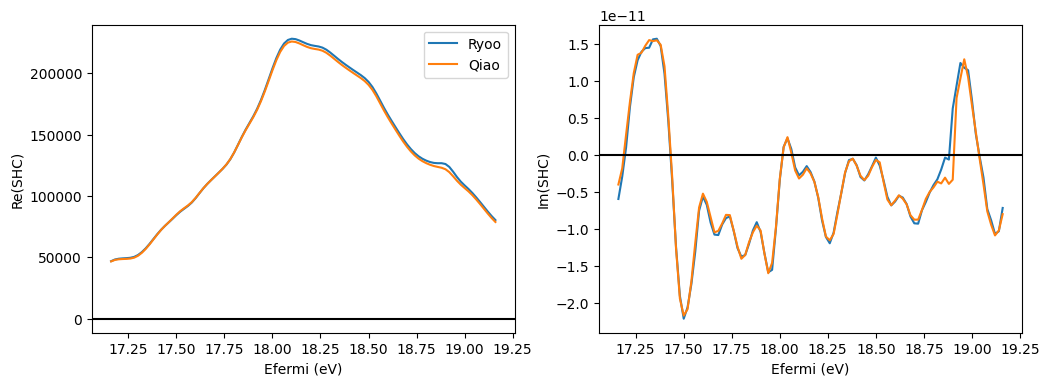

In [11]:
shc_ryoo = result.results["SHC_ryoo"].data[:, 0, 0, 1, 2]
shc_qiao = result.results["SHC_qiao"].data[:, 0, 0, 1, 2]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(efermi_list, shc_ryoo.real, label="Ryoo")
axes[0].plot(efermi_list, shc_qiao.real, label="Qiao")
axes[1].plot(efermi_list, shc_ryoo.imag)
axes[1].plot(efermi_list, shc_qiao.imag)
for ax in axes:
    ax.set_xlabel("Efermi (eV)")
    ax.axhline(0, c="k")
axes[0].set_ylabel("Re(SHC)")
axes[1].set_ylabel("Im(SHC)")
axes[0].legend()
plt.show()

## Dynamic spin Hall conductivity

We calculate the dynamic (i.e. frequency-dependent, AC) spin Hall conductivity. We fix the Fermi energy to the value `efermi` and scan the frequency in the range `omega`.

The `smr_fixed_width` parameter controls the smearing of the frequency-dependent terms (delta functions and principal values).

In [12]:
from wannierberri import calculators as calc

omega = np.linspace(0, 4, 101, True)

kwargs = dict(
    Efermi=np.array([efermi]),
    omega=omega,
    smr_fixed_width = 0.1, # Smearing for frequency in eV
    kBT = 0.026, # Smearing for Fermi level (Fermi-Dirac factor)
)

calculators = dict(
    SHC_ryoo = calc.dynamic.SHC(SHC_type="ryoo", **kwargs),
    SHC_qiao = calc.dynamic.SHC(SHC_type="qiao", **kwargs),
)

In [13]:
nk = 30
grid = wberri.Grid(system, NK=nk)
result = wberri.run(
    system,
    grid=grid,
    calculators=calculators,
)

Minimal symmetric FFT grid :  [4 4 4]
Starting run()
Using the follwing calculators : 
############################################################

 'SHC_ryoo'  :  <wannierberri.calculators.dynamic.SHC object at 0x74a920454740>  : calculator not described
 'SHC_qiao'  :  <wannierberri.calculators.dynamic.SHC object at 0x74a9283190a0>  : calculator not described
############################################################
Calculation on  grid - checking calculators for compatibility
SHC_ryoo <wannierberri.calculators.dynamic.SHC object at 0x74a920454740>
SHC_qiao <wannierberri.calculators.dynamic.SHC object at 0x74a9283190a0>
All calculators are compatible
Grid is regular
The set of k points is a Grid() with NKdiv=[6 6 6], NKFFT=[5 5 5], NKtot=[30 30 30]
generating K_list
Done in 0.000926971435546875 s 
excluding symmetry-equivalent K-points from initial grid
Done in 0.029068470001220703 s 
K_list contains 16 Irreducible points(7.41%) out of initial 6x6x6=216 grid
Done, sum of weights:

(1, 101, 3, 3, 3)
(1, 101, 3, 3, 3)


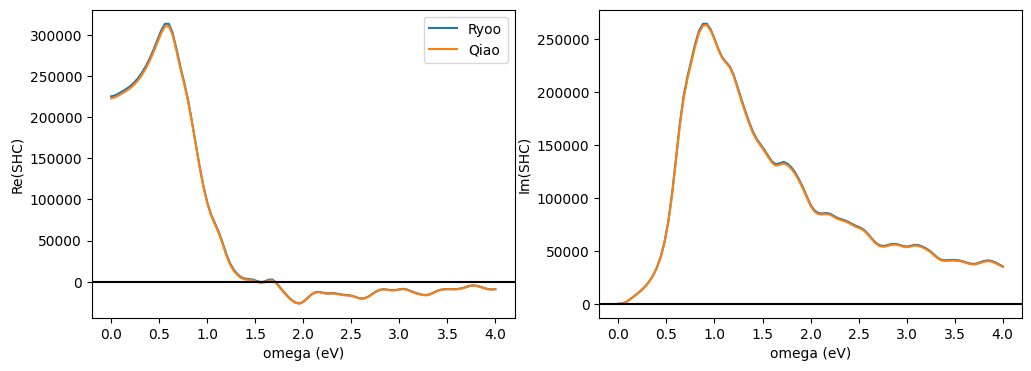

In [15]:
print (result.results["SHC_ryoo"].data.shape)
print (result.results["SHC_qiao"].data.shape)
shc_ryoo = result.results["SHC_ryoo"].data[0, :, 0, 1, 2]
shc_qiao = result.results["SHC_qiao"].data[0, :, 0, 1, 2]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(omega, shc_ryoo.real, label="Ryoo")
axes[0].plot(omega, shc_qiao.real, label="Qiao")
axes[1].plot(omega, shc_ryoo.imag)
axes[1].plot(omega, shc_qiao.imag)
for ax in axes:
    ax.set_xlabel("omega (eV)")
    ax.axhline(0, c="k")
axes[0].set_ylabel("Re(SHC)")
axes[1].set_ylabel("Im(SHC)")
axes[0].legend()
plt.show()

## Spin Berry curvature

To understand the microscopic origin of the spin Hall conductivity, one may inspect the k-resolved spin Berry curvature.
Eq. (\ref{eq:shc}) is recast into the sum of a Berry-curvature-like term, the spin Berry curvature.

The spin Berry curvature is

\begin{equation}
  \Omega^{n, \gamma}_{\alpha\beta}({\bf k}) = -\sum_{m \neq n}\frac{2\textrm{Im}\left[\langle\psi_{n{\bf k}}\vert \frac{1}{2}\{ s^{\gamma}, v_\alpha \} \vert\psi_{m{\bf k}}\rangle\langle\psi_{m{\bf k}}\vert v_\beta\vert\psi_{n{\bf k}}\rangle\right]}{(\varepsilon_{n{\bf k}}-\varepsilon_{m{\bf k}})^2-(i\eta)^2}\,,
  \label{eq:sbc}\tag{2}
\end{equation}

and the k-resolved spin Berry curvature summed over the band index is

\begin{equation}
  \Omega^{\gamma}_{\alpha\beta}({\bf k}) = \sum_{n}f_{n{\bf k}}\Omega^{n, \gamma}_{\alpha\beta}({\bf k})\,.
  \label{eq:sbc_k_resolved}\tag{3}
\end{equation}
\begin{equation}
  \sigma^{{\rm SHC}, \gamma}_{\alpha\beta} = \frac{-e\hbar}{N_k\Omega_c}\sum_{\bf k}\Omega^{\gamma}_{\alpha\beta}({\bf k})
  \label{eq:shc_sbc}\tag{4}
\end{equation}

Therefore, where in the k-space contributes to the total SHC can be investigated using the k-resolved spin Berry curvature.

Here, we compute the spin Berry curvature again using the Ryoo method and the Qiao method.
Note that we pass the spin curren type as a `kwargs_formula` to the calculator, e.g. `kwargs_formula=dict(spin_current_type="ryoo")`.

In [16]:
from wannierberri import calculators as calc
calculators = {}
calculators["tabulate"] = calc.TabulatorAll(
     {
         "Energy": calc.tabulate.Energy(),
         'spin_berry_ryoo': calc.tabulate.SpinBerry(kwargs_formula=dict(spin_current_type="ryoo"), degen_thresh=1e-2),
         'spin_berry_qiao': calc.tabulate.SpinBerry(kwargs_formula=dict(spin_current_type="qiao"), degen_thresh=1e-2),
     },
    ibands=np.arange(system.num_wann),
    mode="path",
 )

In [17]:
path = wberri.Path.from_nodes(
    system,
    nodes=[
        [0.25, 0.75, 0.50], # W
        [0.50, 0.50, 0.50], # L
        [0.00, 0.00, 0.00], # Gamma
        [0.50, 0.00, 0.50], # X
        [0.50, 0.25, 0.75], # W
        [0.00, 0.00, 0.00], # Gamma
    ],
    labels=["W", "L", "$\Gamma$", "X", "W", "$\Gamma$"],
    length=600,
)

result_spin_berry = wberri.run(
    system,
    grid=path,
    calculators=calculators
)

Starting run()
Using the follwing calculators : 
############################################################

 'tabulate'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x74a9284f0a10>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
--------------------------------------------------
 "Energy" : <wannierberri.calculators.tabulate.Energy object at 0x74a9283190a0> : calculator not described

 "spin_berry_ryoo" : <wannierberri.calculators.tabulate.SpinBerry object at 0x74a920454740> : calculator not described

 "spin_berry_qiao" : <wannierberri.calculators.tabulate.SpinBerry object at 0x74a92803db50> : calculator not described

--------------------------------------------------

############################################################
Calculation along a path - checking calculators for compatibility
tabulate <wannierberri.calculators.tabulate.TabulatorAll object at 0x74a9284f0a10>
All calculators are co

/home/stepan/github/wannier-berri/wannierberri/grid/path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


time for processing    643 K-points on  16 processes:     1.8886 ; per K-point          0.0029 ; proc-sec per K-point          0.0470
time1 =  2.384185791015625e-07
Totally processed 643 K-points 
run() finished


Now we sum over bands to compute the k-resolved spin Berry curvature:
$$\Omega^{\gamma}_{\alpha\beta}({\bf k}) = \sum_{n \in {\rm occ.}} \Omega^{n, \gamma}_{\alpha\beta}({\bf k})$$

In [18]:
nk = path.K_list.shape[0]
spin_berry_ryoo = np.zeros((nk, 3, 3, 3))
spin_berry_qiao = np.zeros((nk, 3, 3, 3))

for iband in range(system.num_wann):
    # Get the data for iband-th band
    e = result_spin_berry.results["tabulate"].get_data("Energy", iband)
    spin_berry_ryoo_nk = result_spin_berry.results["tabulate"].get_data("spin_berry_ryoo", iband)
    spin_berry_qiao_nk = result_spin_berry.results["tabulate"].get_data("spin_berry_qiao", iband)

    # Select k-point indices where the iband-th band is occupied
    inds_occupied = e < efermi
    
    # Add the spin Berry curvature of those bands
    spin_berry_ryoo[inds_occupied] += spin_berry_ryoo_nk[inds_occupied]
    spin_berry_qiao[inds_occupied] += spin_berry_qiao_nk[inds_occupied]

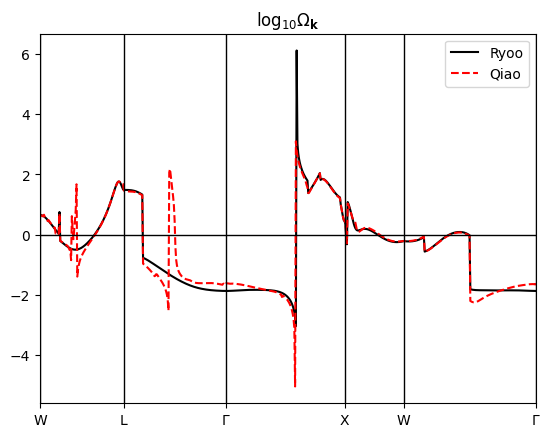

In [19]:
def get_signed_log10(x):
    return np.log10(abs(x)) * np.sign(x)
    
kline = path.getKline()
plt.plot(kline, get_signed_log10(spin_berry_ryoo[:, 0, 1, 2]), "k-", label='Ryoo')
plt.plot(kline, get_signed_log10(spin_berry_qiao[:, 0, 1, 2]), "r--", label='Qiao')

for i in path.labels.keys():
    plt.axvline(kline[i], c="k", lw=1)
plt.xticks([kline[i] for i in path.labels.keys()], path.labels.values())
plt.xlim([min(kline), max(kline)])
plt.axhline(0, c="k", lw=1)
plt.legend()
plt.title("$\mathrm{log}_{10} \Omega_\mathbf{k}$")

plt.show()

You can find that the spin Berry curvature calculated using the Qiao method shows more "wiggles" than the Ryoo method. This numerical difference has been first reported in [T. Ng et al, PRB 104 014412 (2021)](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.104.014412):

>  It is worth
noting that there is jittering along Γ-Z, which occurs in the same path in WTe2 using the same method [22] (Qiao et al). However, such jittering disappears and the spin Berry curvature along Γ-Z becomes a smooth function using the method in Ref. [45] (Ryoo et al).

## Generating .sHu and .sIu from .mmn and .spn: mmn2uHu 

Even if you have not obtained .shu and .sIu from an ab initio code, you can make them from the overlap matrix and the spin matrix. Wannierberri provides the utility `wannierberri.utils.mmn2uHu`, which calculated the matrices `.uHu`, `.uIu`, `.sHu`, and/or `.sIu` from the `.mmn`, `.spn`, `.eig` matrices, and also reduces the number of bands in `.amn`, `.mmn`, `.eig`  and `.spn` files, by means of the sum-over-states formula

\begin{equation}
  \langle u_{m{\bf q}}\vert\hat{s}\hat{H}_{\bf q}\vert u_{n{\bf q}+\mathbf{b}}\rangle \approx \sum_l^{l_{\rm max}}  \left(s_{lm}({\bf q})\right)^* E_{l{\bf q}}   M_{ln}^{\mathbf{b}}({\bf q})\,.
\label{eq:sHu}\tag{5}
\end{equation}

\begin{equation}
  \langle u_{m{\bf q}}\vert\hat{s}\vert u_{n{\bf q}+\mathbf{b}}\rangle \approx \sum_l^{l_{\rm max}}  \left(s_{lm}({\bf q})\right)^*   M_{ln}^{\mathbf{b}}({\bf q})\,.
\label{eq:sIu}\tag{6}
\end{equation}


Here, $l_{\rm max}$ cannot exceed the number of bands included in the Wannier90 calculation (i.e. the `num_bands` parameter in `Pt.win`).

The `mmn2uHu` utility can be particularly useful when the calculation of `sHu` and `sIu` files are not implemented in the DFT code you are using.

In [21]:
from wannierberri.utils import mmn2uHu as mmn2uHu
os.chdir("data_Pt")
mmn2uHu.run_mmn2uHu(PREFIX="Pt", writeSHU=True, writeSIU=True, NBout=18, NBsum=24)
#In case of direct execution of mmn2uHu module,
#python3 -m wannierberri.utils.mmn2uHu Pt NBout=18,NBsum=24,targets=sHu,sIu
# os.chdir("..")

# Rename sHu and sIu files
import shutil
shutil.move("reduced_NB=24/Pt_nbs=24.sHu", "reduced_NB=24/Pt.sHu")
shutil.move("reduced_NB=24/Pt_nbs=24.sIu", "reduced_NB=24/Pt.sIu")

# Copy chk and spn files
shutil.copyfile("Pt.chk", "reduced_NB=24/Pt.chk")
shutil.copyfile("Pt.spn", "reduced_NB=24/Pt.spn")

os.chdir("..")

----------
 MMN  read
---------

k-point 1 of 64
k-point 2 of 64
k-point 3 of 64
k-point 4 of 64
k-point 5 of 64
k-point 6 of 64
k-point 7 of 64
k-point 8 of 64
k-point 9 of 64
k-point 10 of 64
k-point 11 of 64
k-point 12 of 64
k-point 13 of 64
k-point 14 of 64
k-point 15 of 64
k-point 16 of 64
k-point 17 of 64
k-point 18 of 64
k-point 19 of 64
k-point 20 of 64
k-point 21 of 64
k-point 22 of 64
k-point 23 of 64
k-point 24 of 64
k-point 25 of 64
k-point 26 of 64
k-point 27 of 64
k-point 28 of 64
k-point 29 of 64
k-point 30 of 64
k-point 31 of 64
k-point 32 of 64
k-point 33 of 64
k-point 34 of 64
k-point 35 of 64
k-point 36 of 64
k-point 37 of 64
k-point 38 of 64
k-point 39 of 64
k-point 40 of 64
k-point 41 of 64
k-point 42 of 64
k-point 43 of 64
k-point 44 of 64
k-point 45 of 64
k-point 46 of 64
k-point 47 of 64
k-point 48 of 64
k-point 49 of 64
k-point 50 of 64
k-point 51 of 64
k-point 52 of 64
k-point 53 of 64
k-point 54 of 64
k-point 55 of 64
k-point 56 of 64
k-point 57 of 64
k-point

In [23]:
wandata_mmn2uhu = wberri.WannierData.from_w90_files("data_Pt/reduced_NB=24/Pt", files=["chk", "mmn", "eig", "sHu", "sIu", "spn"])
system_mmn2uhu = wberri.System_R.from_wannierdata(wandata_mmn2uhu, berry=True, SHCryoo=True, SHCqiao=True)
system_mmn2uhu.set_structure([[0., 0., 0.]], ["Pt"])
system_mmn2uhu.set_symmetry_from_structure()

Reading restart information from file data_Pt/reduced_NB=24/Pt.chk :
Time to read .chk : 0.002306222915649414
Shells found with weights [0.77529492] and tolerance 7.723368162452873e-16
----------
  sHu   
---------
reading object of class SHU from file data_Pt/reduced_NB=24/Pt.sHu with formatted=False bk_reorder={0: [6, 5, 1, 2, 4, 0, 7, 3], 1: [6, 5, 2, 3, 0, 1, 7, 4], 2: [6, 5, 2, 3, 0, 1, 7, 4], 3: [6, 5, 1, 2, 0, 3, 7, 4], 4: [6, 0, 2, 3, 5, 1, 7, 4], 5: [7, 0, 3, 4, 1, 2, 6, 5], 6: [7, 0, 3, 4, 1, 2, 6, 5], 7: [7, 0, 2, 3, 1, 4, 6, 5], 8: [6, 0, 2, 3, 5, 1, 7, 4], 9: [7, 0, 3, 4, 1, 2, 6, 5], 10: [7, 0, 3, 4, 1, 2, 6, 5], 11: [7, 0, 2, 3, 1, 4, 6, 5], 12: [6, 0, 3, 2, 5, 1, 7, 4], 13: [7, 0, 4, 3, 1, 2, 6, 5], 14: [7, 0, 4, 3, 1, 2, 6, 5], 15: [6, 0, 3, 2, 1, 4, 5, 7], 16: [0, 6, 2, 3, 5, 1, 7, 4], 17: [0, 7, 3, 4, 1, 2, 6, 5], 18: [0, 7, 3, 4, 1, 2, 6, 5], 19: [0, 7, 2, 3, 1, 4, 6, 5], 20: [0, 1, 3, 4, 7, 2, 6, 5], 21: [1, 2, 5, 6, 3, 4, 0, 7], 22: [1, 2, 5, 6, 3, 4, 0, 7], 23: [

In [24]:
from wannierberri import calculators as calc

efermi_list = np.linspace(efermi - 1.0, efermi + 1.0, 101, True)

kwargs = dict(
    Efermi=efermi_list,
    omega=np.array([0.]),
    smr_fixed_width = 0.1, # Smearing for frequency in eV
    kBT = 0.026, # Smearing for Fermi level (Fermi-Dirac factor) in eV (not Kelvin)
)

calculators = dict(
    SHC_ryoo = calc.dynamic.SHC(SHC_type="ryoo", **kwargs),
)

nk = 30
result_pw2w90 = wberri.run(
    system,
    grid=wberri.Grid(system, NK=nk),
    calculators=calculators
)

result_mmn2uhu = wberri.run(
    system_mmn2uhu,
    grid=wberri.Grid(system, NK=nk),
    calculators=calculators
)

Minimal symmetric FFT grid :  [4 4 4]
Starting run()
Using the follwing calculators : 
############################################################

 'SHC_ryoo'  :  <wannierberri.calculators.dynamic.SHC object at 0x74a92072fb90>  : calculator not described
############################################################
Calculation on  grid - checking calculators for compatibility
SHC_ryoo <wannierberri.calculators.dynamic.SHC object at 0x74a92072fb90>
All calculators are compatible
Grid is regular
The set of k points is a Grid() with NKdiv=[6 6 6], NKFFT=[5 5 5], NKtot=[30 30 30]
generating K_list
Done in 0.0014352798461914062 s 
excluding symmetry-equivalent K-points from initial grid
Done in 0.028430938720703125 s 
K_list contains 16 Irreducible points(7.41%) out of initial 6x6x6=216 grid
Done, sum of weights:0.9999999999999997

############################################################
Iteration 0 out of 0 
processing 16 K points : using  16 processes.
# K-points calculated  Wall tim

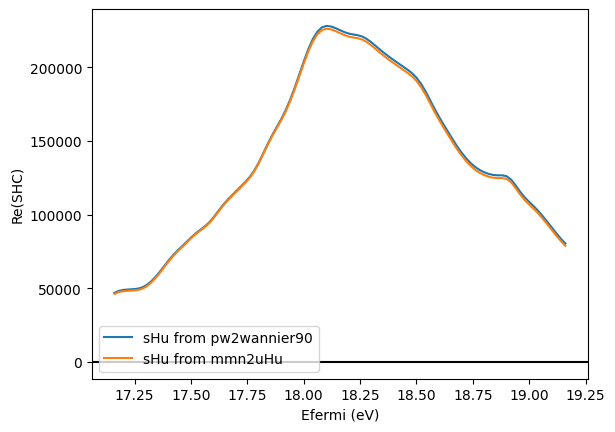

In [25]:
shc_pw2w90 = result_pw2w90.results["SHC_ryoo"].data[:, 0, 0, 1, 2]
shc_mmn2uHu = result_mmn2uhu.results["SHC_ryoo"].data[:, 0, 0, 1, 2]

plt.plot(efermi_list, shc_pw2w90.real, label="sHu from pw2wannier90")
plt.plot(efermi_list, shc_mmn2uHu.real, label="sHu from mmn2uHu")
plt.xlabel("Efermi (eV)")
plt.axhline(0, c="k")
plt.ylabel("Re(SHC)")
plt.legend()
plt.show()

## Further questions

If you are interested, try to answer the following questions:
- Try to converge the calculation using a different value of `smr_fixed_width`. In principle, to achieve an ideal convergence to the zero-smearing limit, one needs to first converge SHC increasing the grid size for a fixed `smr_fixed_width`, and then repeat the procedure with smaller `smr_fixed_width` until convergence.
- What happens if one include more bands in the NSCF calculation? Does the two methods converge to the same result? (To answer this question, one needs to perform additional DFT calculations.)